# Quantitative Market Risk Modeling: VaR & Expected Shortfall

This opening section is a short SPY exploration. The complete, documented SPY-to-portfolio risk study starts below it.

In [31]:
# Import required libraries for data analysis, visualization, and financial calculations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [32]:
# Set portfolio value for VaR/ES calculations
portfolio_value = 1_000_000

### SPY(Single Security)

In [33]:
# Download SPY historical price data from 2010 to 2026
ticker = "SPY"

data = yf.download(
    ticker,
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,84.578484,84.623260,83.220213,83.862034,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503914,85.541231,84.824781,84.996428,126402800


In [34]:
# Display dataset info
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   4024 non-null   float64
 1   (High, SPY)    4024 non-null   float64
 2   (Low, SPY)     4024 non-null   float64
 3   (Open, SPY)    4024 non-null   float64
 4   (Volume, SPY)  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB
None


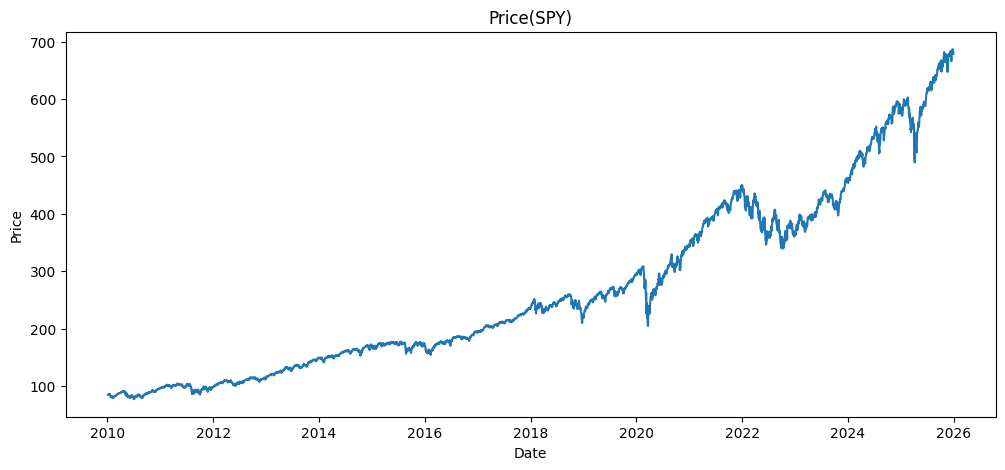

In [35]:
# Plot SPY closing prices over time
prices = data["Close"]["SPY"]

plt.figure(figsize=(12, 5))

plt.plot(prices)

plt.title("Price(SPY)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [36]:
# Calculate daily percentage returns and display summary statistics
returns = prices.pct_change().dropna()

returns.describe()

count    4023.000000
mean        0.000577
std         0.010841
min        -0.109424
25%        -0.003706
50%         0.000705
75%         0.005790
max         0.105019
Name: SPY, dtype: float64

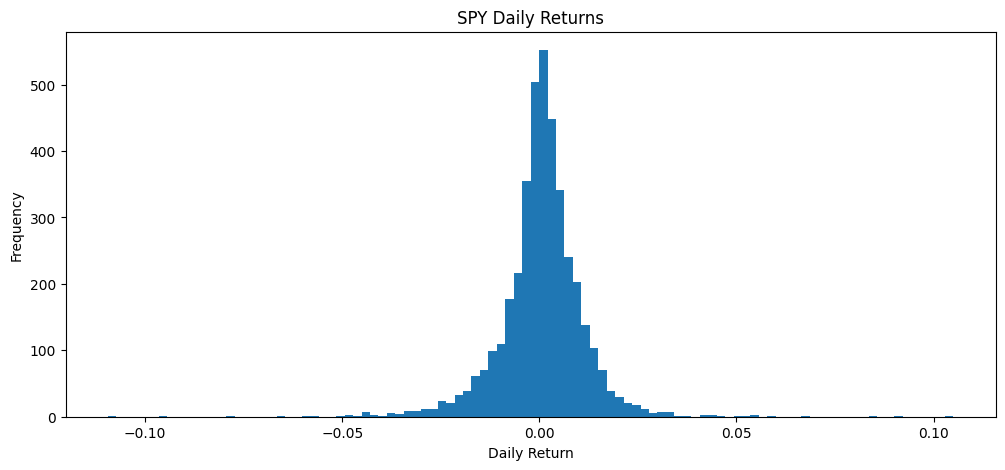

In [37]:
# Plot histogram of daily SPY returns distribution
plt.figure(figsize=(12, 5))

plt.hist(returns, bins=100)

plt.title("SPY Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

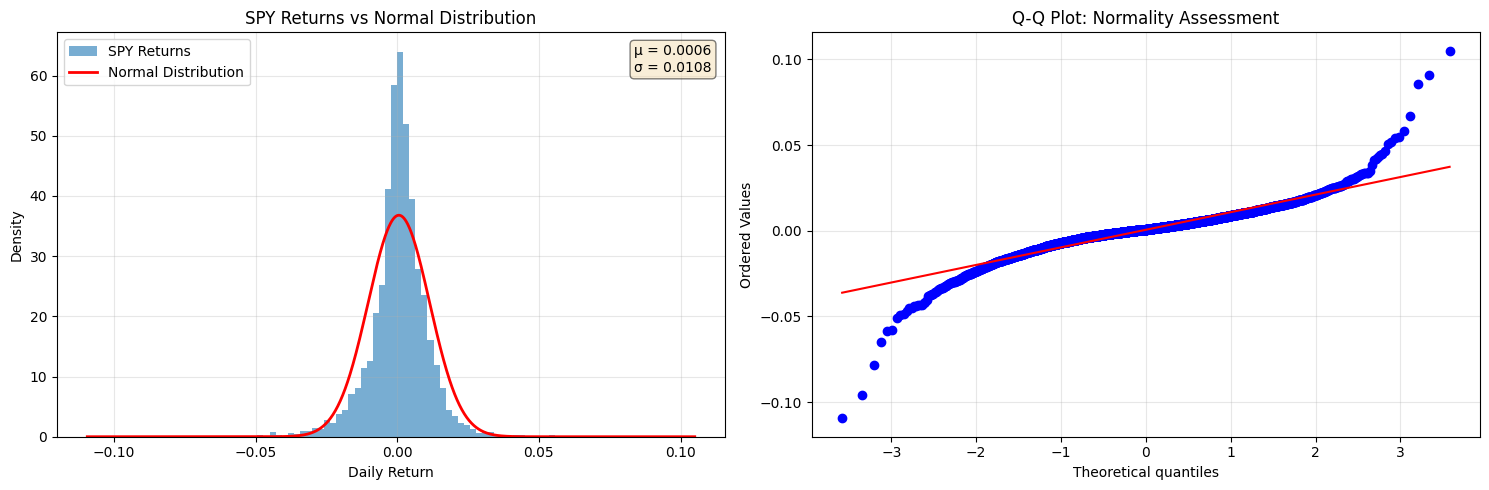


NORMALITY TEST RESULTS (Shapiro-Wilk Test)
Test Statistic: 0.895703
P-Value: 4.515542e-46
----------------------------------------------------------------------
❌ Result: REJECT null hypothesis (α = 0.05)
   Returns do NOT follow normal distribution (statistically significant)
   ⚠️  VaR estimates based on normal distribution may be UNRELIABLE


In [38]:
# Fit normal distribution to returns and compare with actual returns distribution
mu = returns.mean()
sigma = returns.std()

x = np.linspace(
    returns.min(),
    returns.max(),
    1000
)

normal_pdf = stats.norm.pdf(
    x,
    mu,
    sigma
)

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_pvalue = stats.shapiro(returns)

# Create subplots: histogram + normal PDF + Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Histogram with normal distribution overlay
axes[0].hist(
    returns,
    bins=100,
    density=True,
    alpha=0.6,
    label='SPY Returns'
)

axes[0].plot(
    x,
    normal_pdf,
    linewidth=2,
    label='Normal Distribution',
    color='red'
)

# Add mean and sigma text box on histogram
textstr = f'μ = {mu:.4f}\nσ = {sigma:.4f}'
axes[0].text(0.98, 0.97, textstr, transform=axes[0].transAxes, 
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_title("SPY Returns vs Normal Distribution")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Subplot 2: Q-Q plot (quantile-quantile plot)
stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Normality Assessment")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print normality test results
print("\n" + "="*70)
print("NORMALITY TEST RESULTS (Shapiro-Wilk Test)")
print("="*70)
print(f"Test Statistic: {shapiro_stat:.6f}")
print(f"P-Value: {shapiro_pvalue:.6e}")
print("-"*70)

if shapiro_pvalue < 0.05:
    print("❌ Result: REJECT null hypothesis (α = 0.05)")
    print("   Returns do NOT follow normal distribution (statistically significant)")
    print("   ⚠️  VaR estimates based on normal distribution may be UNRELIABLE")
else:
    print("✓ Result: FAIL TO REJECT null hypothesis (α = 0.05)")
    print("   Returns approximately follow normal distribution")
    print("   ✓ Normal distribution assumption is reasonable for VaR")

print("="*70)

In [39]:
# Calculate return distribution statistics (mean, volatility, skewness, kurtosis)
mean_return = returns.mean()
volatility = returns.std()
skewness = returns.skew()
kurtosis = returns.kurtosis()

print("Mean:", mean_return)
print("Volatility:", volatility)
print("Skewness:", skewness)
print("Excess Kurtosis:", kurtosis)

Mean: 0.0005765505376000345
Volatility: 0.010841123223194254
Skewness: -0.33456703115259573
Excess Kurtosis: 12.117392865822685


In [40]:
# Calculate VaR and Expected Shortfall for multiple confidence levels (95%, 99%, 99.9%)
confidence_levels = [95, 99, 99.9]

results = []

for conf_level in confidence_levels:
    conf_decimal = conf_level / 100
    
    # VaR (Return)
    var_return = returns.quantile(1 - conf_decimal)
    var = -var_return
    
    # ES (Expected Shortfall) - average of returns worse than VaR
    es_return = returns[returns <= var_return].mean()
    es = -es_return
    
    # Dollar amounts
    var_dollar = portfolio_value * var
    es_dollar = portfolio_value * es
    
    results.append({
        'Confidence Level (%)': conf_level,
        'VaR (Return %)': f"{var*100:.4f}",
        'VaR (Dollar $)': f"${var_dollar:,.2f}",
        'ES (Return %)': f"{es*100:.4f}",
        'ES (Dollar $)': f"${es_dollar:,.2f}"
    })

results_df = pd.DataFrame(results)
print("\nValue at Risk (VaR) & Expected Shortfall (ES) Analysis for SPY Portfolio ($1,000,000):")
print("="*90)
print(results_df.to_string(index=False))


Value at Risk (VaR) & Expected Shortfall (ES) Analysis for SPY Portfolio ($1,000,000):
 Confidence Level (%) VaR (Return %) VaR (Dollar $) ES (Return %) ES (Dollar $)
                 95.0         1.6527     $16,527.12        2.6257    $26,256.67
                 99.0         3.0755     $30,755.10        4.4167    $44,167.32
                 99.9         5.8523     $58,523.22        8.1372    $81,372.26


# Portfolio Tail-Risk Study: VaR & Expected Shortfall

## Research question

**Which risk model provides the most reliable estimate of portfolio tail risk?**

This notebook starts with SPY and then evaluates a portfolio of SPY, QQQ, TLT, GLD, and IWM. All estimates use a one-day horizon and report losses as positive numbers. Out-of-sample backtesting, not in-sample estimates, determines reliability.

> Data requirement: install yfinance in the selected notebook kernel if needed, then run this notebook from top to bottom.

## Model design and conventions

| Item | Choice |
|---|---|
| Horizon | One trading day |
| Confidence level | 99% (1% left-tail probability) |
| VaR convention | Positive loss threshold; a breach occurs when realised loss exceeds VaR |
| Expected Shortfall | Average loss conditional on exceeding VaR |
| Estimation window | 500 trading days, rolling daily |
| Test set | Most recent 750 trading days, subject to data availability |
| Backtests | Kupiec coverage and Christoffersen independence / conditional coverage |

The Monte Carlo model simulates the fitted normal distribution. It should be close to Parametric VaR apart from simulation noise; simulation by itself does not improve the tail assumption.

In [41]:
# Re-import so the full research workflow is self-contained.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

# Reproducible settings; change these values for sensitivity analysis.
TICKERS = ['SPY', 'QQQ', 'TLT', 'GLD', 'IWM']
WEIGHTS = np.array([0.35, 0.25, 0.15, 0.15, 0.10])
START_DATE = '2010-01-01'
END_DATE = pd.Timestamp.today().normalize()
PORTFOLIO_VALUE = 1_000_000
CONFIDENCE = 0.99
ROLLING_WINDOW = 500
BACKTEST_DAYS = 750
MONTE_CARLO_SIMS = 100_000
MONTE_CARLO_SIMS_ROLLING = 10_000
RANDOM_SEED = 42
SIGNIFICANCE = 0.05

assert np.isclose(WEIGHTS.sum(), 1.0), 'Portfolio weights must sum to 100%.'
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.4f}'.format
print(f'Analysis end date: {END_DATE.date()}')
print(f'Portfolio value: USD {PORTFOLIO_VALUE:,.0f}')

Analysis end date: 2026-08-18
Portfolio value: USD 1,000,000


In [42]:
# Download adjusted prices: auto_adjust accounts for splits and distributions.
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False, group_by='column')
if raw_data.empty:
    raise RuntimeError('No market data were downloaded. Check internet access, tickers, and dates.')

prices = raw_data['Close'].copy()
if isinstance(prices, pd.Series):
    prices = prices.to_frame(name=TICKERS[0])
missing_tickers = set(TICKERS).difference(prices.columns)
if missing_tickers:
    raise ValueError(f'Missing price data for: {sorted(missing_tickers)}')

# Use common trading dates, then calculate fixed-weight, daily rebalanced portfolio returns.
prices = prices.reindex(columns=TICKERS).dropna(how='any')
asset_returns = prices.pct_change().dropna()
portfolio_returns = asset_returns.mul(WEIGHTS, axis=1).sum(axis=1).rename('Portfolio')
weights_table = pd.DataFrame({'Ticker': TICKERS, 'Weight': WEIGHTS}).set_index('Ticker')
display(weights_table.style.format({'Weight': '{:.1%}'}))
print(f'Portfolio return observations: {len(portfolio_returns):,}')

,Weight
Ticker,
SPY,35.0%
QQQ,25.0%
TLT,15.0%
GLD,15.0%
IWM,10.0%


Portfolio return observations: 4,179


In [43]:
# All functions take decimal returns and return positive loss measures in decimal form.
def _clean_returns(returns):
    cleaned = pd.Series(returns, dtype='float64').dropna()
    if len(cleaned) < 30:
        raise ValueError('At least 30 non-missing returns are required for a risk estimate.')
    return cleaned


def estimate_var_es(returns, method, confidence=CONFIDENCE, n_simulations=MONTE_CARLO_SIMS, seed=RANDOM_SEED):
    """Estimate one-day VaR and ES using historical, normal-parametric, or normal Monte Carlo methods."""
    sample = _clean_returns(returns)
    alpha = 1 - confidence
    method = method.lower()
    if method == 'historical':
        var_return = sample.quantile(alpha)
        es_return = sample.loc[sample <= var_return].mean()
    elif method == 'parametric':
        mu, sigma = sample.mean(), sample.std(ddof=1)
        z_alpha = stats.norm.ppf(alpha)
        var_return = mu + sigma * z_alpha
        es_return = mu - sigma * stats.norm.pdf(z_alpha) / alpha
    elif method in {'monte carlo', 'monte_carlo'}:
        mu, sigma = sample.mean(), sample.std(ddof=1)
        simulated_returns = np.random.default_rng(seed).normal(mu, sigma, size=n_simulations)
        var_return = np.quantile(simulated_returns, alpha)
        es_return = simulated_returns[simulated_returns <= var_return].mean()
    else:
        raise ValueError("method must be 'historical', 'parametric', or 'monte carlo'.")
    return {'VaR': -var_return, 'ES': -es_return}


def risk_summary(returns, label, confidence=CONFIDENCE):
    rows = []
    for method in ['historical', 'parametric', 'monte carlo']:
        metrics = estimate_var_es(returns, method, confidence)
        rows.append({
            'Series': label, 'Model': method.replace('_', ' ').title(),
            'VaR (return)': metrics['VaR'], 'ES (return)': metrics['ES'],
            'VaR (USD)': metrics['VaR'] * PORTFOLIO_VALUE,
            'ES (USD)': metrics['ES'] * PORTFOLIO_VALUE,
        })
    return pd.DataFrame(rows)


def display_risk_summary(summary):
    display(summary.style.format({
        'VaR (return)': '{:.2%}', 'ES (return)': '{:.2%}',
        'VaR (USD)': 'USD {:,.0f}', 'ES (USD)': 'USD {:,.0f}'
    }))

## 1. SPY benchmark: distribution and tail-risk estimates

This benchmark isolates model behaviour for SPY. The histogram and Q-Q plot make the normality assumption visible before relying on a normal-parametric estimate.

,Series,Model,VaR (return),ES (return),VaR (USD),ES (USD)
0,SPY,Historical,3.03%,4.38%,"USD 30,316","USD 43,839"
1,SPY,Parametric,2.45%,2.81%,"USD 24,459","USD 28,108"
2,SPY,Monte Carlo,2.46%,2.83%,"USD 24,644","USD 28,348"


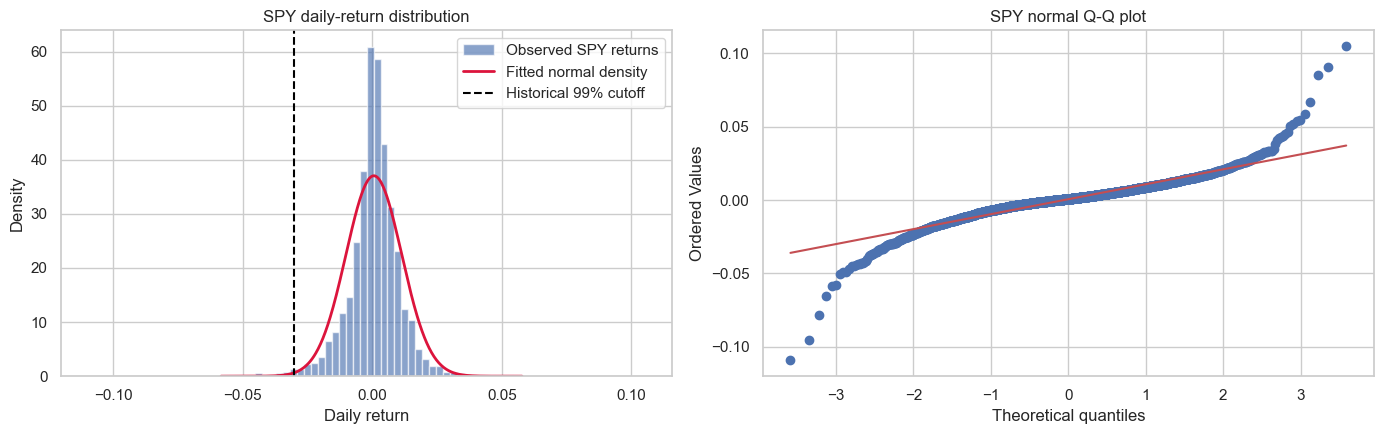

Shapiro-Wilk p-value: 2.246e-46
Small p-values and tail departures in the Q-Q plot caution against relying only on normal-parametric VaR.


In [44]:
spy_returns = asset_returns['SPY']
spy_summary = risk_summary(spy_returns, 'SPY')
display_risk_summary(spy_summary)

mu, sigma = spy_returns.mean(), spy_returns.std(ddof=1)
x = np.linspace(spy_returns.quantile(0.001), spy_returns.quantile(0.999), 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(spy_returns, bins=80, density=True, alpha=0.65, label='Observed SPY returns')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='crimson', lw=2, label='Fitted normal density')
axes[0].axvline(spy_returns.quantile(1 - CONFIDENCE), color='black', ls='--', label=f'Historical {CONFIDENCE:.0%} cutoff')
axes[0].set(title='SPY daily-return distribution', xlabel='Daily return', ylabel='Density')
axes[0].legend()
stats.probplot(spy_returns, dist='norm', plot=axes[1])
axes[1].set_title('SPY normal Q-Q plot')
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_pvalue = stats.shapiro(spy_returns.sample(min(5_000, len(spy_returns)), random_state=RANDOM_SEED))
print(f'Shapiro-Wilk p-value: {shapiro_pvalue:.3e}')
print('Small p-values and tail departures in the Q-Q plot caution against relying only on normal-parametric VaR.')

## 2. Portfolio risk estimates

The portfolio return is the daily weighted sum of component returns, rebalanced to the stated fixed weights every day. VaR is the loss threshold; ES is the average loss beyond it and is therefore the more informative severity measure.

,Series,Model,VaR (return),ES (return),VaR (USD),ES (USD)
0,SPY/QQQ/TLT/GLD/IWM portfolio,Historical,2.21%,3.19%,"USD 22,060","USD 31,917"
1,SPY/QQQ/TLT/GLD/IWM portfolio,Parametric,1.86%,2.14%,"USD 18,571","USD 21,353"
2,SPY/QQQ/TLT/GLD/IWM portfolio,Monte Carlo,1.87%,2.15%,"USD 18,712","USD 21,536"


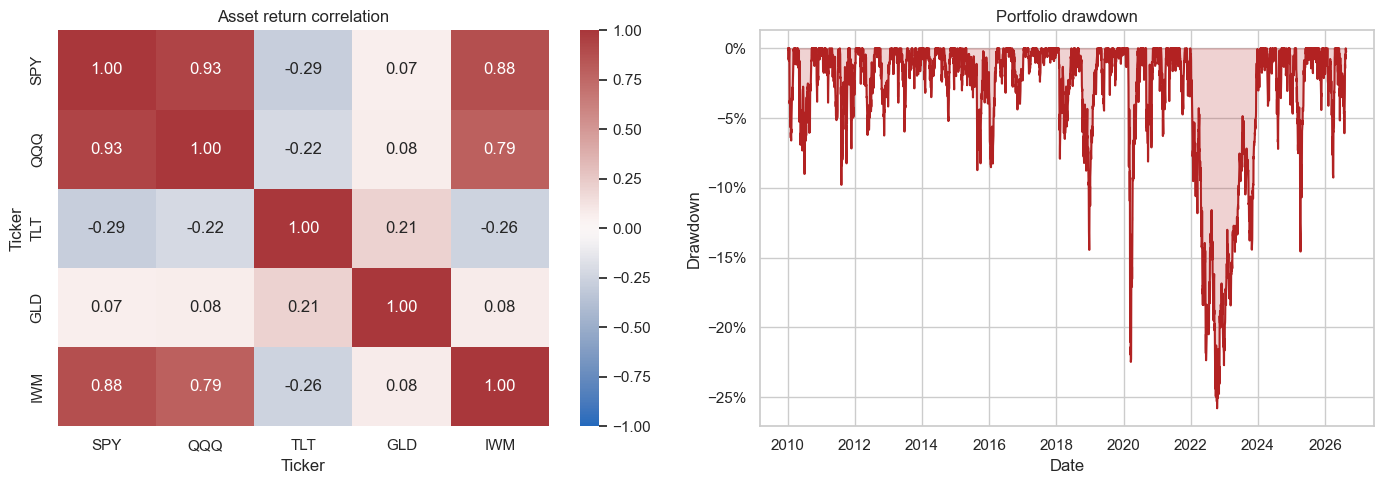

Maximum historical drawdown: -25.80%


In [45]:
portfolio_summary = risk_summary(portfolio_returns, 'SPY/QQQ/TLT/GLD/IWM portfolio')
display_risk_summary(portfolio_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(asset_returns.corr(), annot=True, cmap='vlag', vmin=-1, vmax=1, fmt='.2f', ax=axes[0])
axes[0].set_title('Asset return correlation')
growth = (1 + portfolio_returns).cumprod()
drawdown = growth / growth.cummax() - 1
axes[1].plot(drawdown, color='firebrick')
axes[1].fill_between(drawdown.index, drawdown, 0, color='firebrick', alpha=0.2)
axes[1].set(title='Portfolio drawdown', xlabel='Date', ylabel='Drawdown')
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
plt.show()
print(f'Maximum historical drawdown: {drawdown.min():.2%}')

## 3. Rolling VaR forecasts and backtesting

Each forecast uses only the preceding 500 daily returns, avoiding look-ahead bias. A VaR exception occurs if the next realised loss is greater than the VaR forecast. At 99% confidence, an adequately calibrated model should have roughly 1% exceptions.

The Kupiec test checks whether exception frequency is correct. Christoffersen's independence test checks whether exceptions cluster. Their combined conditional-coverage test is the primary VaR calibration test used here.

In [46]:
def rolling_risk_forecasts(returns, method, window=ROLLING_WINDOW, confidence=CONFIDENCE):
    """Create strictly out-of-sample one-day-ahead VaR and ES forecasts."""
    series = _clean_returns(returns)
    if len(series) <= window:
        raise ValueError('The rolling window is longer than the available return history.')

    # Calculate only the formal test window to keep rolling Monte Carlo practical.
    first_forecast = max(window, len(series) - BACKTEST_DAYS)
    records = []
    for end_loc in range(first_forecast, len(series)):
        estimation_sample = series.iloc[end_loc - window:end_loc]
        metrics = estimate_var_es(estimation_sample, method, confidence,
                                  n_simulations=MONTE_CARLO_SIMS_ROLLING, seed=RANDOM_SEED + end_loc)
        realised_return = series.iloc[end_loc]
        records.append({'Date': series.index[end_loc], 'Realised return': realised_return,
                        'Realised loss': -realised_return, 'VaR': metrics['VaR'], 'ES': metrics['ES']})

    forecast = pd.DataFrame(records).set_index('Date')
    forecast['Exception'] = forecast['Realised loss'] > forecast['VaR']
    return forecast


rolling_forecasts = {
    method: rolling_risk_forecasts(portfolio_returns, method)
    for method in ['historical', 'parametric', 'monte carlo']
}
for method, frame in rolling_forecasts.items():
    print(f'{method.title():<12}: {len(frame):,} forecasts; {frame["Exception"].sum():,} exceptions')

Historical  : 750 forecasts; 9 exceptions
Parametric  : 750 forecasts; 12 exceptions
Monte Carlo : 750 forecasts; 12 exceptions


In [47]:
def _clip_probability(probability, epsilon=1e-12):
    return float(np.clip(probability, epsilon, 1 - epsilon))


def kupiec_test(exceptions, alpha=1 - CONFIDENCE):
    # Kupiec proportion-of-failures test; null hypothesis is correct exception frequency.
    hits = np.asarray(exceptions, dtype=int)
    n_obs, n_exceptions = len(hits), hits.sum()
    if n_obs == 0:
        raise ValueError('No forecasts supplied for backtesting.')
    observed_rate, alpha = _clip_probability(n_exceptions / n_obs), _clip_probability(alpha)
    log_null = n_exceptions * np.log(alpha) + (n_obs - n_exceptions) * np.log(1 - alpha)
    log_alt = n_exceptions * np.log(observed_rate) + (n_obs - n_exceptions) * np.log(1 - observed_rate)
    lr_uc = -2 * (log_null - log_alt)
    return {'LR_uc': lr_uc, 'p_uc': stats.chi2.sf(lr_uc, df=1)}


def christoffersen_test(exceptions):
    # Christoffersen independence test; null hypothesis is no exception clustering.
    hits = np.asarray(exceptions, dtype=int)
    if len(hits) < 2:
        raise ValueError('At least two forecasts are required for the independence test.')
    previous, current = hits[:-1], hits[1:]
    n00 = int(((previous == 0) & (current == 0)).sum())
    n01 = int(((previous == 0) & (current == 1)).sum())
    n10 = int(((previous == 1) & (current == 0)).sum())
    n11 = int(((previous == 1) & (current == 1)).sum())
    pi = _clip_probability((n01 + n11) / (n00 + n01 + n10 + n11))
    pi0 = _clip_probability(n01 / max(n00 + n01, 1))
    pi1 = _clip_probability(n11 / max(n10 + n11, 1))
    log_independent = (n00 + n10) * np.log(1 - pi) + (n01 + n11) * np.log(pi)
    log_markov = (n00 * np.log(1 - pi0) + n01 * np.log(pi0) +
                  n10 * np.log(1 - pi1) + n11 * np.log(pi1))
    lr_ind = -2 * (log_independent - log_markov)
    return {'LR_ind': lr_ind, 'p_ind': stats.chi2.sf(lr_ind, df=1)}


def backtest_summary(forecasts, alpha=1 - CONFIDENCE, significance=SIGNIFICANCE):
    rows = []
    for method, frame in forecasts.items():
        kupiec = kupiec_test(frame['Exception'], alpha)
        christoffersen = christoffersen_test(frame['Exception'])
        lr_cc = kupiec['LR_uc'] + christoffersen['LR_ind']
        p_cc = stats.chi2.sf(lr_cc, df=2)
        tail_losses = frame.loc[frame['Exception'], 'Realised loss']
        realised_tail_loss = tail_losses.mean() if len(tail_losses) else np.nan
        forecast_es = frame.loc[frame['Exception'], 'ES'].mean() if len(tail_losses) else np.nan
        es_ratio = realised_tail_loss / forecast_es if pd.notna(realised_tail_loss) else np.nan
        rows.append({
            'Model': method.replace('_', ' ').title(), 'Forecasts': len(frame),
            'Exceptions': int(frame['Exception'].sum()), 'Exception rate': frame['Exception'].mean(),
            'Expected rate': alpha, 'Kupiec p-value': kupiec['p_uc'],
            'Independence p-value': christoffersen['p_ind'],
            'Conditional coverage p-value': p_cc, 'ES severity ratio': es_ratio,
            'Pass conditional coverage': p_cc > significance,
        })
    return pd.DataFrame(rows)


backtests = backtest_summary(rolling_forecasts)
display(backtests.style.format({
    'Exception rate': '{:.2%}', 'Expected rate': '{:.2%}',
    'Kupiec p-value': '{:.3f}', 'Independence p-value': '{:.3f}',
    'Conditional coverage p-value': '{:.3f}', 'ES severity ratio': '{:.2f}x'
}))
print('ES severity ratio = realised mean loss on VaR-exception days / mean forecast ES on those days.')
print('A ratio near 1 is desirable; above 1 indicates exception losses were more severe than forecast ES.')

,Model,Forecasts,Exceptions,Exception rate,Expected rate,Kupiec p-value,Independence p-value,Conditional coverage p-value,ES severity ratio,Pass conditional coverage
0,Historical,750,9,1.20%,1.00%,0.594,0.091,0.208,1.09x,True
1,Parametric,750,12,1.60%,1.00%,0.129,0.180,0.128,1.27x,True
2,Monte Carlo,750,12,1.60%,1.00%,0.129,0.180,0.128,1.26x,True


ES severity ratio = realised mean loss on VaR-exception days / mean forecast ES on those days.
A ratio near 1 is desirable; above 1 indicates exception losses were more severe than forecast ES.


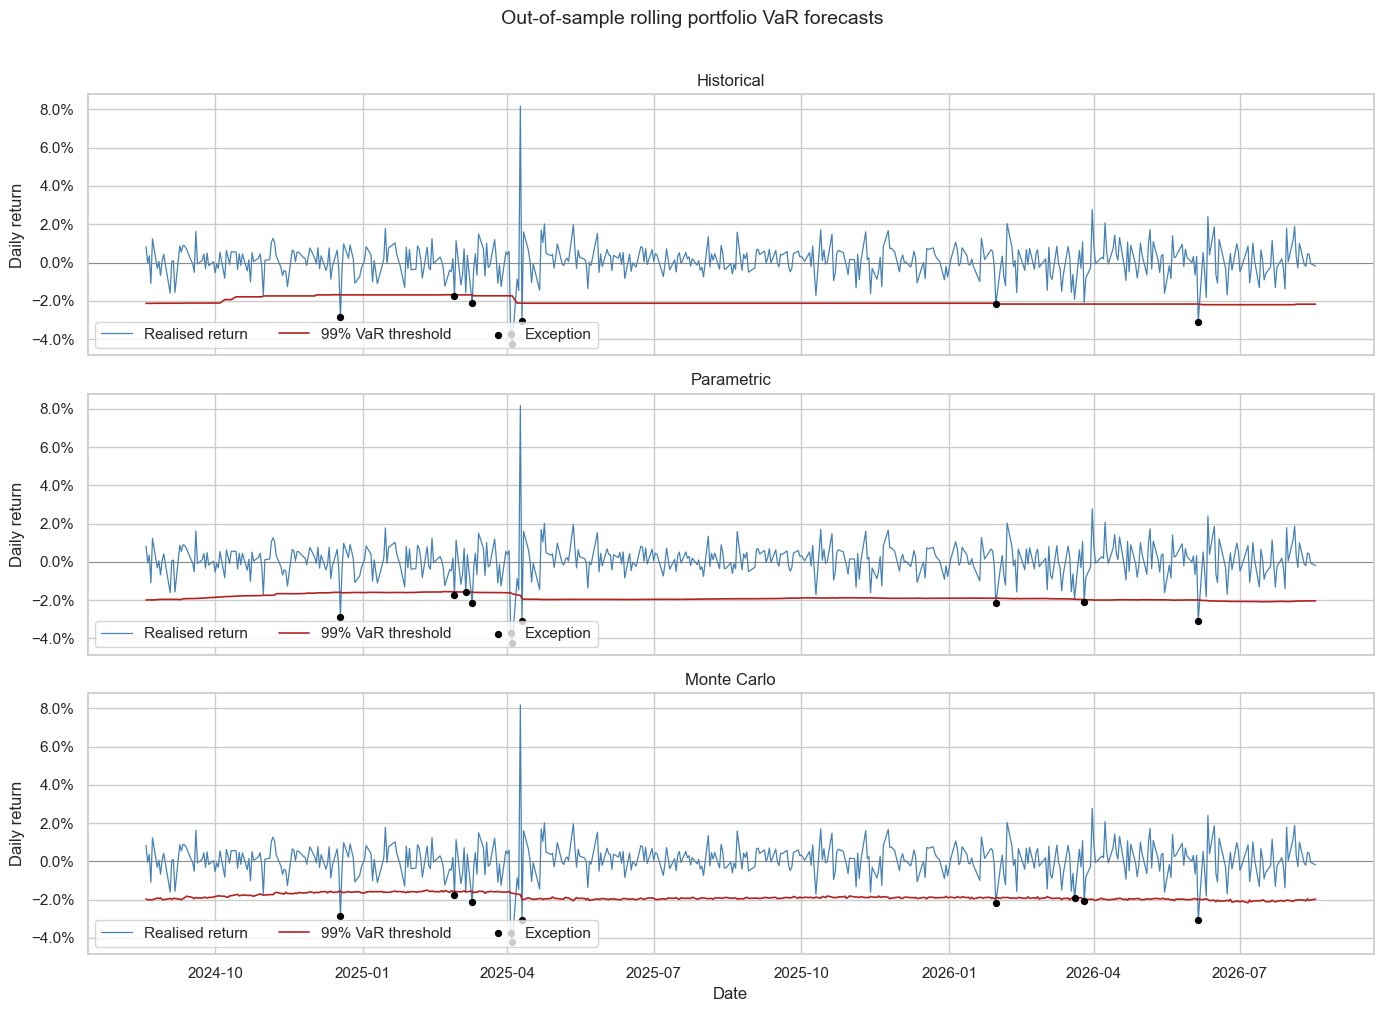

In [48]:
# Returns are compared with the negative VaR threshold because VaR is stored as a positive loss.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, (method, frame) in zip(axes, rolling_forecasts.items()):
    chart = frame.tail(min(500, len(frame)))
    axis.plot(chart.index, chart['Realised return'], color='steelblue', lw=0.9, label='Realised return')
    axis.plot(chart.index, -chart['VaR'], color='firebrick', lw=1.2, label=f'{CONFIDENCE:.0%} VaR threshold')
    exception_days = chart.loc[chart['Exception']]
    axis.scatter(exception_days.index, exception_days['Realised return'], color='black', s=18, zorder=3, label='Exception')
    axis.axhline(0, color='grey', lw=0.6)
    axis.set_title(method.replace('_', ' ').title())
    axis.set_ylabel('Daily return')
    axis.yaxis.set_major_formatter('{x:.1%}')
    axis.legend(loc='lower left', ncol=3)
axes[-1].set_xlabel('Date')
fig.suptitle('Out-of-sample rolling portfolio VaR forecasts', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Stress testing

VaR is a probability-based measure and can understate losses outside its calibration sample. The historical windows below show realised multi-day portfolio shocks; the hypothetical scenarios impose coherent cross-asset shocks. They are not probability forecasts and should be reviewed alongside VaR and ES.

In [49]:
def cumulative_return(return_series, start, end):
    # Compound all available returns in an inclusive historical stress window.
    period = return_series.loc[start:end]
    return (1 + period).prod() - 1 if not period.empty else np.nan


historical_scenarios = {
    'COVID-19 market shock (2020-02-19 to 2020-03-23)': ('2020-02-19', '2020-03-23'),
    '2022 inflation and rate shock (2022-01-03 to 2022-10-14)': ('2022-01-03', '2022-10-14'),
    '2023 banking stress (2023-03-08 to 2023-03-13)': ('2023-03-08', '2023-03-13'),
}
historical_stress = pd.DataFrame([
    {'Scenario': name, 'Portfolio return': cumulative_return(portfolio_returns, *dates)}
    for name, dates in historical_scenarios.items()
])
historical_stress['Dollar P/L'] = historical_stress['Portfolio return'] * PORTFOLIO_VALUE

worst_day = portfolio_returns.idxmin()
historical_stress = pd.concat([historical_stress, pd.DataFrame([{
    'Scenario': f'Worst observed single day ({worst_day.date()})',
    'Portfolio return': portfolio_returns.loc[worst_day],
    'Dollar P/L': portfolio_returns.loc[worst_day] * PORTFOLIO_VALUE,
}])], ignore_index=True)

# Stylised one-day shocks. Rows are intentionally severe but plausible joint moves.
hypothetical_asset_shocks = pd.DataFrame({
    'SPY': [-0.20, -0.10, -0.12],
    'QQQ': [-0.24, -0.14, -0.15],
    'TLT': [0.06, -0.12, -0.05],
    'GLD': [0.08, -0.08, -0.07],
    'IWM': [-0.25, -0.15, -0.18],
}, index=['Equity crash / flight to quality', 'Inflation shock / rates up', 'Liquidity shock / broad de-risking'])
hypothetical_stress = hypothetical_asset_shocks.copy()
hypothetical_stress['Portfolio return'] = hypothetical_asset_shocks[TICKERS].dot(WEIGHTS)
hypothetical_stress['Dollar P/L'] = hypothetical_stress['Portfolio return'] * PORTFOLIO_VALUE

print('Historical stress results')
display(historical_stress.style.format({'Portfolio return': '{:.2%}', 'Dollar P/L': 'USD {:,.0f}'}))
print('Hypothetical one-day stress results')
display(hypothetical_stress.style.format({
    **{ticker: '{:.1%}' for ticker in TICKERS},
    'Portfolio return': '{:.2%}', 'Dollar P/L': 'USD {:,.0f}'
}))

Historical stress results


,Scenario,Portfolio return,Dollar P/L
0,COVID-19 market shock (2020-02-19 to 2020-03-23),-21.85%,"USD -218,530"
1,2022 inflation and rate shock (2022-01-03 to 2022-10-14),-25.41%,"USD -254,129"
2,2023 banking stress (2023-03-08 to 2023-03-13),-0.93%,"USD -9,346"
3,Worst observed single day (2020-03-16),-7.35%,"USD -73,514"


Hypothetical one-day stress results


,SPY,QQQ,TLT,GLD,IWM,Portfolio return,Dollar P/L
Equity crash / flight to quality,-20.0%,-24.0%,6.0%,8.0%,-25.0%,-13.40%,"USD -134,000"
Inflation shock / rates up,-10.0%,-14.0%,-12.0%,-8.0%,-15.0%,-11.50%,"USD -115,000"
Liquidity shock / broad de-risking,-12.0%,-15.0%,-5.0%,-7.0%,-18.0%,-11.55%,"USD -115,500"


## 5. Answering the research question

A model is more reliable only if its exceptions are both correctly frequent and non-clustered in the unseen test period. Among models that pass conditional coverage, the notebook ranks the estimate whose ES severity ratio is closest to one. If no model passes, it reports the least-rejected model and flags that the model set should be extended with filtered historical simulation, EWMA or GARCH volatility, or Student-t innovations.

In [50]:
ranking = backtests.copy()
ranking['ES distance from 1'] = (ranking['ES severity ratio'] - 1).abs()
passing_models = ranking.loc[ranking['Pass conditional coverage']].sort_values('ES distance from 1')

if not passing_models.empty:
    selected = passing_models.iloc[0]
    decision = 'passes conditional coverage and has the best ES severity calibration among passing models'
else:
    selected = ranking.sort_values('Conditional coverage p-value', ascending=False).iloc[0]
    decision = 'is the least rejected model, but no candidate passes conditional coverage'

print('MODEL SELECTION BASED ON OUT-OF-SAMPLE EVIDENCE')
print('-' * 58)
print(f'Recommended model: {selected["Model"]}')
print(f'Why: It {decision}.')
print(f'Exception rate: {selected["Exception rate"]:.2%} versus expected {selected["Expected rate"]:.2%}.')
print(f'Conditional-coverage p-value: {selected["Conditional coverage p-value"]:.3f}.')
print(f'ES severity ratio: {selected["ES severity ratio"]:.2f}x.')

print('Interpretation notes:')
print('- Historical VaR captures empirical skew and fat tails but may be slow after a volatility-regime change.')
print('- Parametric normal VaR is stable and transparent, but normal tails can be too light during stress.')
print('- Normal Monte Carlo adds simulation noise without fixing the normal-tail assumption.')
print('- ES must be monitored with VaR because it measures severity after the VaR threshold is breached.')

MODEL SELECTION BASED ON OUT-OF-SAMPLE EVIDENCE
----------------------------------------------------------
Recommended model: Historical
Why: It passes conditional coverage and has the best ES severity calibration among passing models.
Exception rate: 1.20% versus expected 1.00%.
Conditional-coverage p-value: 0.208.
ES severity ratio: 1.09x.
Interpretation notes:
- Historical VaR captures empirical skew and fat tails but may be slow after a volatility-regime change.
- Parametric normal VaR is stable and transparent, but normal tails can be too light during stress.
- Normal Monte Carlo adds simulation noise without fixing the normal-tail assumption.
- ES must be monitored with VaR because it measures severity after the VaR threshold is breached.
